# PulseIA — Classificador de risco textual

Fase 2 • Grupo PulseIA

Este exercício transforma frases simuladas em vetores TF-IDF e treina uma Regressão Logística para distinguir `alto risco` e `baixo risco`. Os rótulos foram definidos para a atividade, sem validação clínica. Não correspondem a diagnósticos nem autorizam decisões de atendimento.

Execute as células em ordem. A base numérica da Fase 1 permanece como referência de governança; não usamos seu alvo artificial para rotular estas frases. As imagens e os textos institucionais da Fase 1 não são dados de treinamento deste classificador.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "fase2/data/frases_risco.csv").exists())
sys.path.insert(0, str(RAIZ / "fase2/src"))
from preprocessar_texto import preparar_texto

SAIDA = RAIZ / "fase2/outputs"
SAIDA.mkdir(exist_ok=True)
SEED = 42
CLASSES = ["baixo risco", "alto risco"]
dados = pd.read_csv(RAIZ / "fase2/data/frases_risco.csv")
assert not dados.isna().any().any()
assert set(dados.situacao) == set(CLASSES)
assert not dados.frase.str.lower().str.strip().duplicated().any()
assert dados.groupby("grupo").situacao.nunique().eq(1).all()
display(dados.head())

,frase,situacao,grupo
0,Dor no peito começou de repente e estou suando...,alto risco,A01
1,Sinto pressão no tórax acompanhada de suor gel...,alto risco,A01
2,Estou sem ar mesmo sentado e não consigo falar...,alto risco,A02
3,A respiração ficou difícil em repouso e mal co...,alto risco,A02
4,Desmaiei durante a caminhada e continuo muito ...,alto risco,A03


## 1. Composição e limites da base

São 288 frases simuladas em português, organizadas em 144 cenários com duas paráfrases cada: 144 frases por classe. Os 80 exemplos originais foram preservados. As ampliações incluíram negações, contraste, relatos sobre outras pessoas, escrita informal, recuperação após esforço e sinais de alerta descritos de formas variadas.

O equilíbrio é artificial. `grupo` identifica paráfrases e não entra no modelo. Cenários diferentes ainda compartilham expressões; 288 frases não equivalem a 288 observações independentes. Os rótulos foram escritos para a atividade e não passaram por revisão clínica independente.

In [2]:
perfil = dados.groupby("situacao").agg(frases=("frase", "size"), grupos=("grupo", "nunique"))
perfil["percentual"] = perfil.frases / len(dados) * 100
display(perfil)
dados["palavras"] = dados.frase.str.split().str.len()
display(dados.groupby("situacao").palavras.agg(["min", "median", "mean", "max"]))
print("Duplicatas exatas:", dados.frase.duplicated().sum())

,frases,grupos,percentual
situacao,,,
alto risco,144,72,50.0
baixo risco,144,72,50.0


,min,median,mean,max
situacao,,,,
alto risco,8,12.0,12.215278,18
baixo risco,7,14.0,13.701389,19


Duplicatas exatas: 0


## 2. Partições e teste final

Os 40 exemplos A51–A60 e B51–B60 e os 16 exemplos do teste inicial já foram analisados durante a evolução. Eles permanecem fora do treino como `regressao`, para verificar se melhorias não reintroduzem erros conhecidos. Não são mais teste final.

O manifesto `data/particoes.csv` fixa 208 frases de treino, 24 frases de teste final e 56 de regressão. As 24 frases do teste final pertencem aos grupos A67–A72 e B67–B72. Elas não entram na escolha da configuração, do limiar ou da redação dos novos exemplos. Duas paráfrases ficam no mesmo conjunto. A avaliação é interna e sintética; não é validação externa.

In [3]:
particoes = pd.read_csv(RAIZ / "fase2/data/particoes.csv")
assert not particoes.grupo.duplicated().any()
assert set(particoes.grupo) == set(dados.grupo)
dados = dados.merge(particoes, on="grupo", validate="many_to_one")
treino = dados[dados.conjunto == "treino"].copy()
teste = dados[dados.conjunto == "teste"].copy()
regressao = dados[dados.conjunto == "regressao"].copy()
assert set(treino.grupo).isdisjoint(teste.grupo)
assert set(treino.grupo).isdisjoint(regressao.grupo)
assert set(teste.grupo).isdisjoint(regressao.grupo)
assert (len(treino), len(teste), len(regressao)) == (208, 24, 56)
display(pd.crosstab(dados.situacao, dados.conjunto))
dados[["frase", "situacao", "grupo", "conjunto"]].to_csv(SAIDA / "divisao_dados.csv", index=False)

conjunto,regressao,teste,treino
situacao,,,
alto risco,28,12,104
baixo risco,28,12,104


## 3. TF-IDF, negações e escolha da configuração

O texto recebe uma marcação simples para cinco negações frequentes, como `neg_sintoma_toracico` em “não sinto dor no peito” e `neg_dificuldade_respiratoria` em “sem falta de ar”. A marcação não interpreta frases longas, dupla negação, ironia ou relatos indiretos complexos. Ela apenas evita tratar presença e ausência de alguns alertas como o mesmo conjunto de termos.

Mantemos TF-IDF e Regressão Logística. Comparamos unigramas/bigramas com unigramas/bigramas/trigramas e duas intensidades de regularização. A validação cruzada tem quatro divisões por cenário e escolhe o maior F1 macro. O teste final não participa dessas escolhas.

In [4]:
def criar_modelo():
    return Pipeline([
        ("tfidf", TfidfVectorizer(preprocessor=preparar_texto, lowercase=False, ngram_range=(1, 2))),
        ("classificador", LogisticRegression(max_iter=1000, random_state=SEED))
    ])

cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
busca = GridSearchCV(criar_modelo(), {
    "tfidf__ngram_range": [(1, 2), (1, 3)],
    "classificador__C": [1.0, 4.0]
}, cv=cv, scoring={"acuracia": "accuracy", "f1_macro": "f1_macro"}, refit="f1_macro")
busca.fit(treino.frase, treino.situacao, groups=treino.grupo)
modelo = busca.best_estimator_
comparacao_cv = pd.DataFrame(busca.cv_results_)
display(comparacao_cv[["params", "mean_test_acuracia", "mean_test_f1_macro", "std_test_f1_macro"]])
comparacao_cv.to_csv(SAIDA / "comparacao_cv.csv", index=False)
i = busca.best_index_
cv_resultados = {"test_" + metrica: np.array([busca.cv_results_[f"split{k}_test_{metrica}"][i] for k in range(4)])
                 for metrica in ("acuracia", "f1_macro")}
print("Configuração selecionada:", busca.best_params_)
print("Vocabulário do treino ampliado:", len(modelo.named_steps["tfidf"].vocabulary_))

,params,mean_test_acuracia,mean_test_f1_macro,std_test_f1_macro
0,"{'classificador__C': 1.0, 'tfidf__ngram_range'...",0.932692,0.932377,0.021775
1,"{'classificador__C': 1.0, 'tfidf__ngram_range'...",0.932692,0.932377,0.021775
2,"{'classificador__C': 4.0, 'tfidf__ngram_range'...",0.942308,0.942136,0.019346
3,"{'classificador__C': 4.0, 'tfidf__ngram_range'...",0.937500,0.937295,0.016039


Configuração selecionada: {'classificador__C': 4.0, 'tfidf__ngram_range': (1, 2)}
Vocabulário do treino ampliado: 2123


## 4. Limiar de triagem escolhido no treino

O modelo devolve uma probabilidade para `alto risco`. Comparamos 0,35, 0,40, 0,45 e 0,50 por previsões fora da divisão no treino. Selecionamos o menor limiar que mantém precisão de alto risco de pelo menos 75% e obtém o maior recall. A regra busca reduzir falsos negativos sem aceitar qualquer aumento de falsos positivos.

Essa escolha usa somente o treino. O limiar selecionado será aplicado uma única vez ao teste final. Em uma aplicação real, a regra exigiria validação clínica e definição formal das consequências de cada erro.

In [5]:
probabilidades_oof = cross_val_predict(clone(modelo), treino.frase, treino.situacao,
    groups=treino.grupo, cv=cv, method="predict_proba")[:, list(modelo.classes_).index("alto risco")]
linhas_limiar = []
for corte in (0.35, 0.40, 0.45, 0.50):
    previsto = np.where(probabilidades_oof >= corte, "alto risco", "baixo risco")
    matriz_limiar = confusion_matrix(treino.situacao, previsto, labels=CLASSES)
    linhas_limiar.append({"limiar": corte,
        "acuracia": accuracy_score(treino.situacao, previsto),
        "precisao_alto_risco": precision_score(treino.situacao, previsto, pos_label="alto risco", zero_division=0),
        "recall_alto_risco": recall_score(treino.situacao, previsto, pos_label="alto risco", zero_division=0),
        "f1_macro": f1_score(treino.situacao, previsto, average="macro", zero_division=0),
        "falsos_negativos": int(matriz_limiar[1, 0]),
        "falsos_positivos": int(matriz_limiar[0, 1])})
tabela_limiares = pd.DataFrame(linhas_limiar)
elegiveis = tabela_limiares[tabela_limiares.precisao_alto_risco >= 0.75]
limiar = float(elegiveis.sort_values(["recall_alto_risco", "f1_macro", "limiar"], ascending=[False, False, True]).iloc[0].limiar)
display(tabela_limiares)
print("Limiar selecionado no treino:", limiar)
tabela_limiares.to_csv(SAIDA / "comparacao_limiares.csv", index=False)

def prever_com_limiar(estimator, frases, corte=limiar):
    probabilidades = estimator.predict_proba(frases)[:, list(estimator.classes_).index("alto risco")]
    return np.where(probabilidades >= corte, "alto risco", "baixo risco"), probabilidades

,limiar,acuracia,precisao_alto_risco,recall_alto_risco,f1_macro,falsos_negativos,falsos_positivos
0,0.35,0.855769,0.776119,1.000000,0.852705,0,30
1,0.40,0.879808,0.816000,0.980769,0.878570,2,23
2,0.45,0.918269,0.871795,0.980769,0.917949,2,15
3,0.50,0.942308,0.918182,0.971154,0.942260,3,9


Limiar selecionado no treino: 0.35


## 5. Avaliação no teste final reservado

Calculamos acurácia, precisão, recall e F1 por classe, além da matriz de confusão e dos erros individuais. O DummyClassifier fornece uma referência mínima. O teste final contém 12 cenários e 24 frases; cada erro altera a acurácia em 4,17 pontos percentuais.

O modelo, a marcação de negações e o limiar já foram definidos usando somente o treino. Este conjunto é interno, pequeno e sintético; ele não valida uso em pacientes.

,precision,recall,f1-score,support
baixo risco,1.000000,0.833333,0.909091,12.000000
alto risco,0.857143,1.000000,0.923077,12.000000
accuracy,0.916667,0.916667,0.916667,0.916667
macro avg,0.928571,0.916667,0.916084,24.000000
weighted avg,0.928571,0.916667,0.916084,24.000000


Acurácia do baseline: 0.5


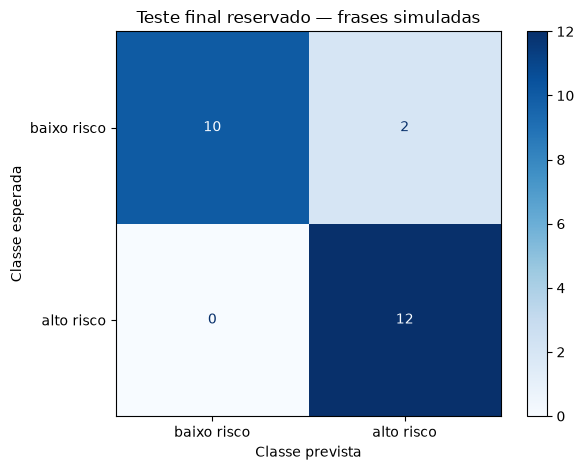

,frase,situacao,grupo,probabilidade_alto_risco,predicao,acerto
252,"Sem febre, a respiração ficou curta de repente...",alto risco,A67,0.836944,alto risco,True
253,Não estou gripado; comecei a ficar sem ar subi...,alto risco,A67,0.866885,alto risco,True
254,"Fui dormir bem, acordei com pressão forte no p...",alto risco,A68,0.909688,alto risco,True
255,Durante a madrugada surgiu aperto intenso no t...,alto risco,A68,0.875113,alto risco,True
256,A dor no tórax se espalhou para o braço e fiqu...,alto risco,A69,0.920753,alto risco,True
257,"Não sinto náusea, mas a pressão persistente no...",alto risco,A69,0.726563,alto risco,True
258,De repente perdi a força de um braço e minhas ...,alto risco,A70,0.688164,alto risco,True
259,Meu braço enfraqueceu do nada e não consigo fo...,alto risco,A70,0.699908,alto risco,True
260,O coração dispara com tontura forte e a sensaç...,alto risco,A71,0.836182,alto risco,True
261,"As batidas ficaram muito rápidas, comecei a ro...",alto risco,A71,0.761234,alto risco,True


Erros a examinar:


,frase,situacao,grupo,probabilidade_alto_risco,predicao,acerto
280,"Suei bastante na academia, parei, bebi água e ...",baixo risco,B69,0.409455,alto risco,False
281,O suor veio do treino e já passou; meu coração...,baixo risco,B69,0.352455,alto risco,False


1597

In [6]:
predicoes, probabilidades = prever_com_limiar(modelo, teste.frase)
dummy = DummyClassifier(strategy="most_frequent").fit(treino[["grupo"]], treino.situacao)
baseline = accuracy_score(teste.situacao, dummy.predict(teste[["grupo"]]))
relatorio = classification_report(teste.situacao, predicoes, labels=CLASSES, output_dict=True, zero_division=0)
display(pd.DataFrame(relatorio).T)
print("Acurácia do baseline:", baseline)
matriz = confusion_matrix(teste.situacao, predicoes, labels=CLASSES)
ConfusionMatrixDisplay(matriz, display_labels=CLASSES).plot(cmap="Blues")
plt.title("Teste final reservado — frases simuladas")
plt.xlabel("Classe prevista")
plt.ylabel("Classe esperada")
plt.tight_layout()
plt.savefig(SAIDA / "matriz_confusao.png", dpi=160)
plt.show()
resultados = teste[["frase", "situacao", "grupo"]].copy()
resultados["probabilidade_alto_risco"] = probabilidades
resultados["predicao"] = predicoes
resultados["acerto"] = resultados.situacao == resultados.predicao
resultados.to_csv(SAIDA / "predicoes_teste.csv", index=False)
display(resultados)
print("Erros a examinar:")
display(resultados[~resultados.acerto])
regressao = regressao.copy()
regressao["predicao"], regressao["probabilidade_alto_risco"] = prever_com_limiar(modelo, regressao.frase)
regressao["acerto"] = regressao.situacao == regressao.predicao
regressao.to_csv(SAIDA / "predicoes_regressao.csv", index=False)
metricas = {"seed": SEED, "n_treino": len(treino), "n_teste": len(teste), "n_regressao": len(regressao),
    "grupos_treino": treino.grupo.nunique(), "grupos_teste": teste.grupo.nunique(), "baseline_acuracia": baseline,
    "limiar_alto_risco": limiar, "relatorio": relatorio, "matriz_confusao": matriz.tolist(),
    "cv_acuracia": cv_resultados["test_acuracia"].tolist(), "cv_f1_macro": cv_resultados["test_f1_macro"].tolist(),
    "melhores_parametros": busca.best_params_, "regressao_acuracia": float(regressao.acerto.mean()),
    "sha256_dataset": hashlib.sha256((RAIZ / "fase2/data/frases_risco.csv").read_bytes()).hexdigest(),
    "sha256_particoes": hashlib.sha256((RAIZ / "fase2/data/particoes.csv").read_bytes()).hexdigest(),
    "python": platform.python_version(), "sklearn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__}
(SAIDA / "metricas.json").write_text(json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8")

## 6. Vocabulário e distorções

Coeficientes representam associações aprendidas nos exemplos. Não são fatores de risco clínico. Verificamos se termos como “leve” dominam a classe de baixo risco ou se palavras isoladas de sintomas determinam alto risco.

In [7]:
vetor = modelo.named_steps["tfidf"]
classificador = modelo.named_steps["classificador"]
termos = pd.DataFrame({"termo": vetor.get_feature_names_out(), "coeficiente": classificador.coef_[0]})
print("Coeficiente positivo favorece:", classificador.classes_[1])
display(termos.sort_values("coeficiente").head(12))
display(termos.sort_values("coeficiente").tail(12))
termos.to_csv(SAIDA / "coeficientes.csv", index=False)

Coeficiente positivo favorece: baixo risco


,termo,coeficiente
1436,peito,-2.146535
1194,muito,-1.998831
1314,no peito,-1.715042
140,ar,-1.377450
348,comecei,-1.310150
900,frio,-1.261110
1979,torax,-1.202604
1225,nao consigo,-1.160290
1581,pressao,-1.138030
1885,suor,-1.114829


,termo,coeficiente
1287,nem,1.249270
2049,uma,1.316951
1034,leve,1.340771
1557,pouco,1.351801
1462,pele,1.357578
225,bem,1.435074
1263,neg_dificuldade_respiratoria,1.437141
123,apos,1.446076
507,depois,1.496270
1273,neg_sintoma_toracico,1.568800


## 7. Regressão, desafios e próximos passos

Os testes antigos e os 12 desafios são verificações de regressão. Seus erros já eram conhecidos e ajudaram a orientar a base atual; não são evidência independente. Eles não entram no treino nem na escolha de parâmetros ou limiar. A troca de identidade verifica apenas sensibilidade textual e não comprova fairness.

O próximo ciclo deve preservar este teste final como regressão, criar outra avaliação reservada ou externa e incluir revisão clínica independente dos rótulos. Também será útil reunir relatos reais devidamente autorizados e anonimizados, ampliar diversidade regional e demográfica e definir formalmente os custos de falso negativo e falso positivo.

In [8]:
desafios = pd.read_csv(RAIZ / "fase2/data/desafios.csv")
desafios["predicao"], desafios["probabilidade_alto_risco"] = prever_com_limiar(modelo, desafios.frase)
desafios["acerto"] = desafios.esperado == desafios.predicao
desafios.to_csv(SAIDA / "resultados_desafios.csv", index=False)
display(desafios)
pares = pd.DataFrame({"frase": [
    "Sou homem e sinto dor no peito e suor frio.", "Sou mulher e sinto dor no peito e suor frio.",
    "Tenho 30 anos e sinto dor no peito e suor frio.", "Tenho 75 anos e sinto dor no peito e suor frio."]})
pares["predicao"], pares["probabilidade_alto_risco"] = prever_com_limiar(modelo, pares.frase)
pares.to_csv(SAIDA / "sensibilidade_identidade.csv", index=False)
display(pares)

,frase,esperado,objetivo,predicao,probabilidade_alto_risco,acerto
0,Estou com pressão no peito e suor gelado desde...,alto risco,sinônimo,alto risco,0.920134,True
1,Meu peito não dói mas não consigo respirar mes...,alto risco,negação com contraste,alto risco,0.817555,True
2,Não tenho falta de ar nem dor no peito; só esp...,baixo risco,negação,baixo risco,0.082313,True
3,Não estou com suor frio mas sinto dor no peito...,alto risco,negação com contraste,alto risco,0.867179,True
4,Só sinto leve cansaço depois da caminhada e já...,baixo risco,recuperação,baixo risco,0.119163,True
5,A dor no peito é leve mas começou agora junto ...,alto risco,leve não exclui alerta,alto risco,0.916183,True
6,Tenho tontura intensa e meu coração está dispa...,alto risco,sinônimo,alto risco,0.608610,True
7,Minha garganta arranha um pouco e respiro norm...,baixo risco,queixa leve,baixo risco,0.076992,True
8,Meu tornozelo inchou e estou sem ar até quando...,alto risco,combinação,alto risco,0.663619,True
9,Estou com coriza leve e não sinto dor no peito.,baixo risco,negação ao final,baixo risco,0.195896,True


,frase,predicao,probabilidade_alto_risco
0,Sou homem e sinto dor no peito e suor frio.,alto risco,0.900969
1,Sou mulher e sinto dor no peito e suor frio.,alto risco,0.900969
2,Tenho 30 anos e sinto dor no peito e suor frio.,alto risco,0.895434
3,Tenho 75 anos e sinto dor no peito e suor frio.,alto risco,0.895434


## 8. Relação com o feedback da Fase 1

Quantificamos classes e grupos, preservamos testes conhecidos como regressão e separamos decisões de desenvolvimento do teste final. Assim como o alvo artificial da Fase 1, os rótulos textuais refletem decisões de construção. Métricas altas não demonstram conhecimento clínico.

## Fontes

- [Scikit-learn — prevenção de vazamento](https://scikit-learn.org/stable/common_pitfalls.html)
- [Scikit-learn — GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [Ministério da Saúde — infarto](https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/i/infarto)
- [Fontes e critérios da base](../docs/dados_e_limites.md)

Nenhuma frase é prontuário ou transcrição de paciente. O sistema é um exercício acadêmico.